In [1]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

import time

In [2]:
def assemble_K_sinus(N, a_func):
    """Stivhedsmatrix for sinusbasis med generel a(x)."""
    K = np.zeros((N, N))
    x = np.linspace(0, 1, 1000)
    for k in range(1, N + 1):
        dpsi_k = np.cos(k*np.pi*x)*k*np.pi  # den afledede af sin(k*pi*x)
        for l in range(1, N + 1):
            dpsi_l = np.cos(l*np.pi*x)*l*np.pi  # den afledede af sin(l*pi*x)
            K[k-1, l-1] = np.trapz(a_func(x)*dpsi_k*dpsi_l,x)  # integrer a(x)*dpsi_k*dpsi_l med np.trapezoid
    return K

def assemble_p_sinus(N, p_func):
    """Lastvektor for sinusbasis med generel p(x)."""
    x = np.linspace(0, 1, 1000)
    p_vec = np.zeros(N)
    for k in range(1, N + 1):
        psi_k = np.sin(k*np.pi*x)  # beregn psi_k = sin(k*pi*x)
        p_vec[k-1] = np.trapz(p_func(x)*psi_k,x)  # integrer p(x)*psi_k med np.trapezoid
    return p_vec

a_func = lambda x: np.where(x < 0.5, 2.0, 1.0)  # definer a(x) med np.where
p_func = lambda x: np.where(x < 3/5, 20, 0)  # definer p(x) med np.where

In [6]:
# (a) Saml K og p for N = 10
N = 10
K_sin = assemble_K_sinus(N, a_func)
p_sin = assemble_p_sinus(N, p_func)

# undersøg K, f.eks. med plt.spy eller print
print(K_sin)
print(np.vstack(p_sin))

[[ 7.40220330e+00  2.09439251e+00 -8.88178420e-16 -8.37752863e-01
  -1.55431223e-15  5.38550973e-01 -2.66453526e-15 -3.98922044e-01
  -3.77475828e-15  3.17319645e-01]
 [ 2.09439251e+00  2.96088132e+01  1.13097569e+01 -2.66453526e-15
  -7.48004724e+00 -6.21724894e-15  6.84181753e+00 -9.10382880e-15
  -6.60979426e+00 -7.54951657e-15]
 [-8.88178420e-16  1.13097569e+01  6.66198297e+01  1.61567156e+01
  -5.32907052e-15 -6.28311540e+00 -1.15463195e-14  4.11253717e+00
  -1.42108547e-14 -3.10695314e+00]
 [-8.37752863e-01 -2.66453526e-15  1.61567156e+01  1.18435253e+02
   3.49067145e+01 -7.10542736e-15 -1.86594101e+01 -7.10542736e-15
   1.56600505e+01 -3.55271368e-15]
 [-1.55431223e-15 -7.48004724e+00 -5.32907052e-15  3.49067145e+01
   1.85055083e+02  4.28397056e+01 -1.42108547e-14 -1.61104726e+01
  -2.66453526e-14  1.04716519e+01]
 [ 5.38550973e-01 -6.21724894e-15 -6.28311540e+00 -7.10542736e-15
   4.28397056e+01  2.66479319e+02  7.10487068e+01 -3.55271368e-14
  -3.39298298e+01 -2.84217094e-14

[[ 1.09128558]
 [ 0.13011469]
 [-0.01996409]
 [ 0.01408975]
 [ 0.01728023]
 [-0.0019387 ]
 [-0.00201037]
 [ 0.00460192]
 [ 0.00184954]
 [-0.00121279]]
u hat <class 'numpy.ndarray'> 200 [0.00000000e+00 2.28872235e-02 4.57507280e-02 6.85669495e-02
 9.13126332e-02 1.13964984e-01 1.36501813e-01 1.58901681e-01
 1.81144028e-01 2.03209304e-01 2.25079085e-01 2.46736176e-01
 2.68164706e-01 2.89350211e-01 3.10279699e-01 3.30941699e-01
 3.51326302e-01 3.71425176e-01 3.91231572e-01 4.10740307e-01
 4.29947733e-01 4.48851686e-01 4.67451425e-01 4.85747542e-01
 5.03741874e-01 5.21437383e-01 5.38838037e-01 5.55948671e-01
 5.72774845e-01 5.89322688e-01 6.05598744e-01 6.21609808e-01
 6.37362769e-01 6.52864447e-01 6.68121446e-01 6.83140001e-01
 6.97925849e-01 7.12484101e-01 7.26819136e-01 7.40934509e-01
 7.54832875e-01 7.68515944e-01 7.81984440e-01 7.95238098e-01
 8.08275674e-01 8.21094979e-01 8.33692939e-01 8.46065669e-01
 8.58208569e-01 8.70116439e-01 8.81783607e-01 8.93204072e-01
 9.04371649e-01 9.1528

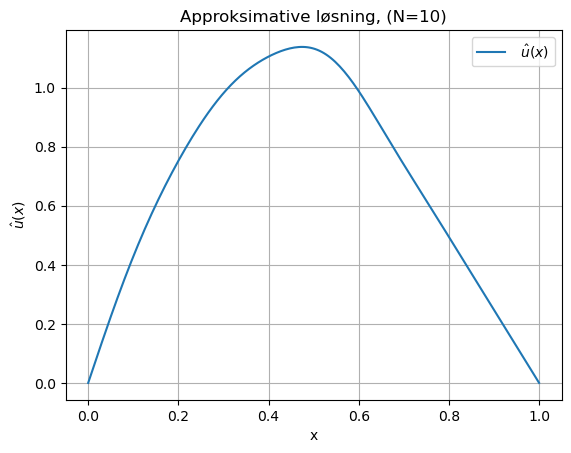

In [ ]:
# (b) Løs systemet og plot løsningen
# løs K*u = p og plot u_hat(x) = sum u_k*sin(k*pi*x)
u=np.linalg.solve(K_sin, p_sin)
print(np.vstack(u))

x_plot = np.linspace(0, 1, 200)
u_hat = np.zeros_like(x_plot)

for k in range(1, N + 1):
    u_hat += u[k-1] * np.sin(k * np.pi * x_plot)

print("u hat", type(u_hat), len(u_hat), u_hat)

# Plot den eksakte løsning u = 0.5*x*(1-x) hvis a=1, p=1
plt.figure()
plt.plot(x_plot, u_hat, label=r' $\hat{u}(x)$')
plt.xlabel('x')
plt.ylabel(r'$\hat{u}(x)$')
plt.legend()
plt.grid(True)
plt.title(f"Approksimative løsning, (N={N})")
plt.show()